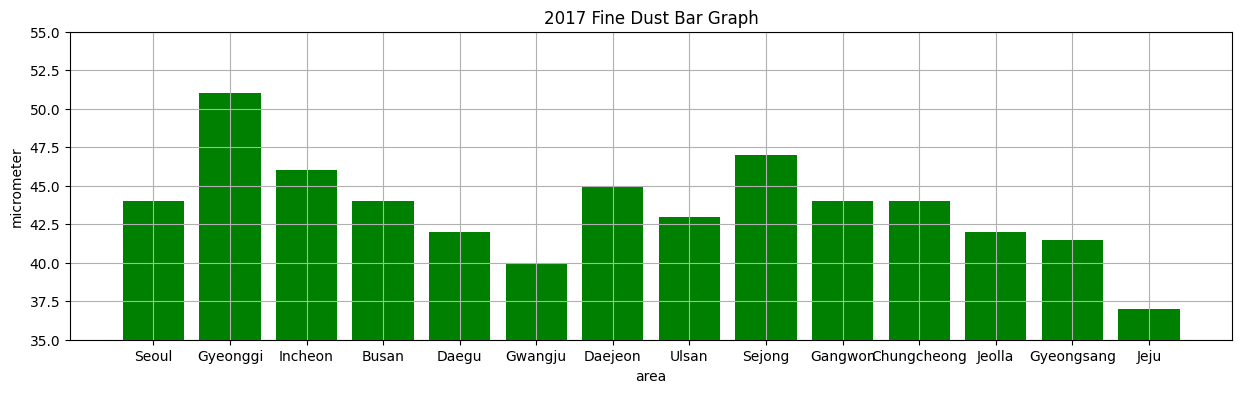

In [1]:
# 1번 문제 : ① = plt.bar

import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_excel("fine_dust.xlsx", index_col="area")
data2017 = data[2017]

plt.figure(figsize=(15,4))
plt.bar(data2017.index, data2017, color="g")
plt.ylim(35,55)
plt.xlabel("area")
plt.ylabel("micrometer")
plt.title("2017 Fine Dust Bar Graph")
plt.grid()
plt.show()

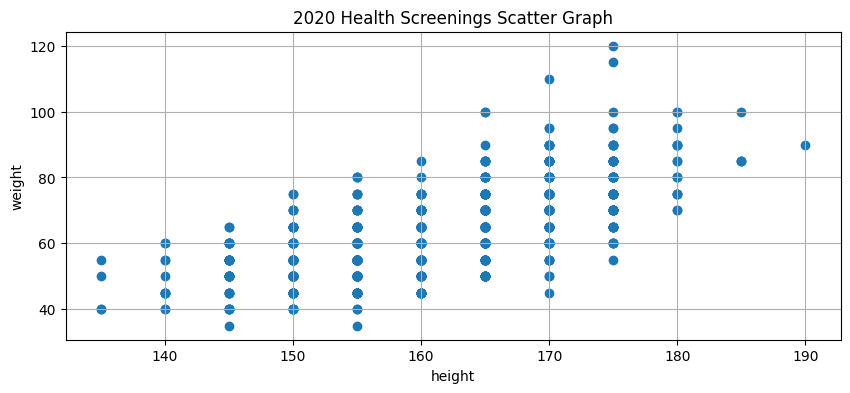

In [2]:
# 2번 문제 : ① = plt.scatter

import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_excel("health_screenings_2020_1000ea.xlsx")
heightdata = data["height"]
weightdata = data["weight"]

plt.figure(figsize=(10,4))
plt.scatter(heightdata, weightdata)
plt.xlabel("height")
plt.ylabel("weight")
plt.title("2020 Health Screenings Scatter Graph")
plt.grid()
plt.show()

In [3]:
# 문항 3~9 공통 데이터

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_excel('health_screenings_2020_1000ea.xlsx')

# data6 : 분석에 필요한 컬럼만 추출 후, 코드값을 문자열로 변환
data6 = data.loc[:, ['gender','height','weight','waist','drinking','smoking']]
data6['gender']   = data6['gender'].replace({1: 'Male', 2: 'Female'})
data6['drinking'] = data6['drinking'].replace({0: 'Non-drinking', 1: 'Drinking'})
data6['smoking']  = data6['smoking'].replace({1: 'Non-smoking', 2: 'Non-smoking', 3: 'Smoking'})

# male_data, female_data : data6를 성별로 분리
male_data   = data6.loc[data6.gender=='Male',   ['gender','weight','waist','drinking','smoking']]
female_data = data6.loc[data6.gender=='Female', ['gender','weight','waist','drinking','smoking']]

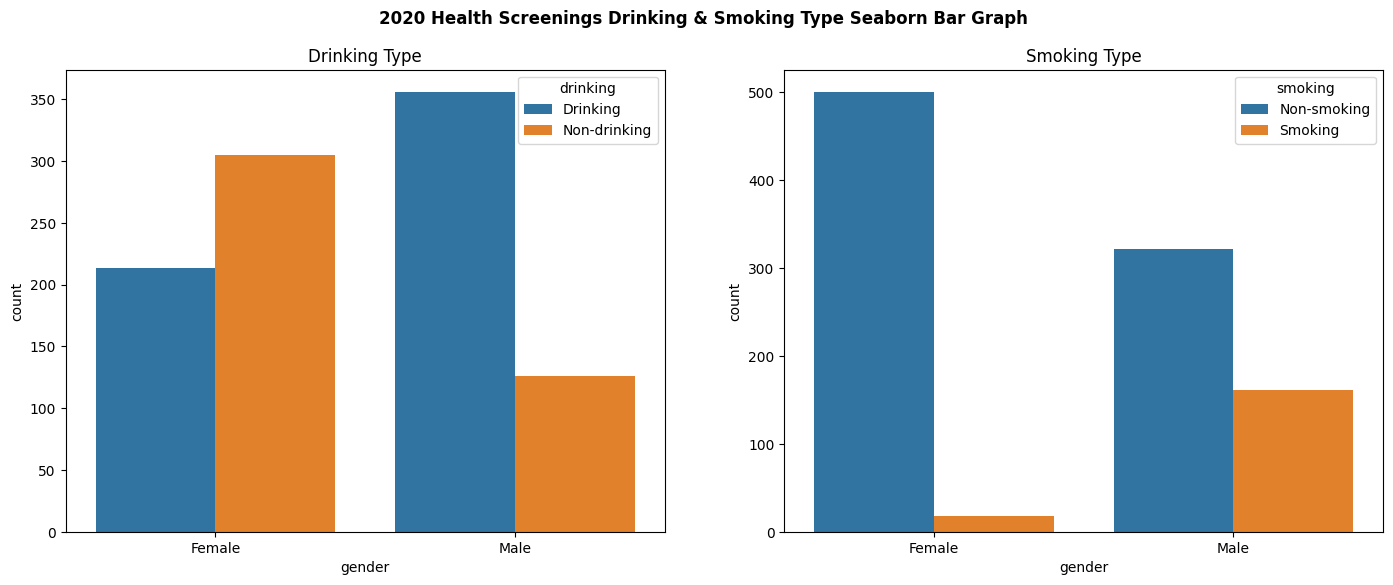

In [4]:
# 3번 문제 : ① = add_subplot, ② = barplot

# 성별·음주여부, 성별·흡연여부 조합별 빈도수 집계
drinking = data6.groupby(['gender','drinking']).size().reset_index(name='count')
smoking = data6.groupby(['gender','smoking']).size().reset_index(name='count')

fig = plt.figure(figsize=(17,6))

area1 = fig.add_subplot(1,2,1)
area2 = fig.add_subplot(1,2,2)

ax1 = sns.barplot(data=drinking, x='gender', y='count', hue='drinking', ax=area1)
ax2 = sns.barplot(data=smoking,  x='gender', y='count', hue='smoking',   ax=area2)

fig.suptitle('2020 Health Screenings Drinking & Smoking Type Seaborn Bar Graph', fontweight='bold')
area1.set_title('Drinking Type')
area2.set_title('Smoking Type')

plt.show()

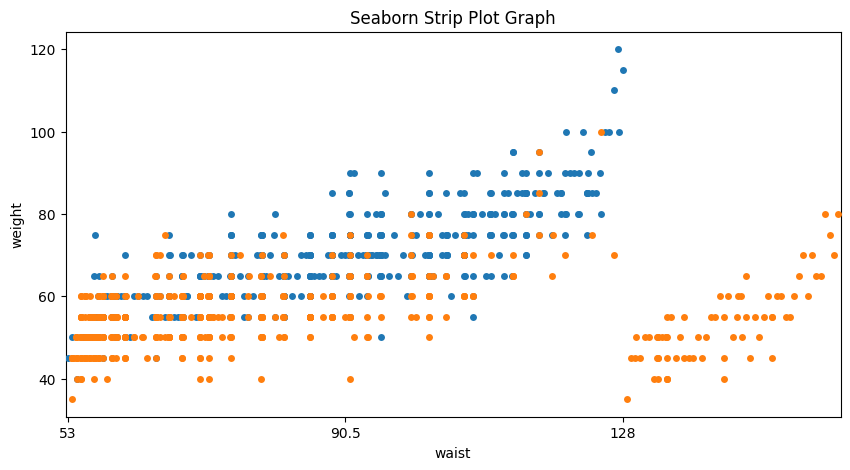

In [5]:
# 4번 문제 : ① = stripplot

plt.figure(figsize=(10,5))
plt.title('Seaborn Strip Plot Graph')

sns.stripplot(data=male_data,   x='waist', y='weight')
sns.stripplot(data=female_data, x='waist', y='weight')

plt.xticks(np.arange(0,127,63), labels=[53, 90.5, 128])
plt.show()

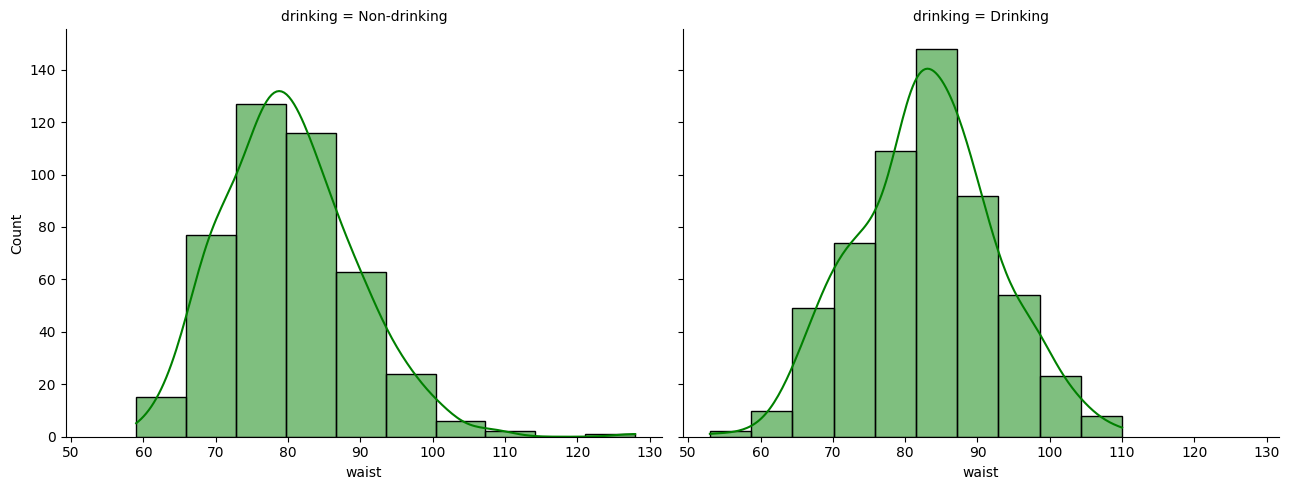

In [6]:
# 5번 문제 : ① = FacetGrid, ② = map

fg = sns.FacetGrid(data6, col='drinking', height=5, aspect=1.3)
fg.map(sns.histplot, 'waist', bins=10, color='g', kde=True)

plt.show()

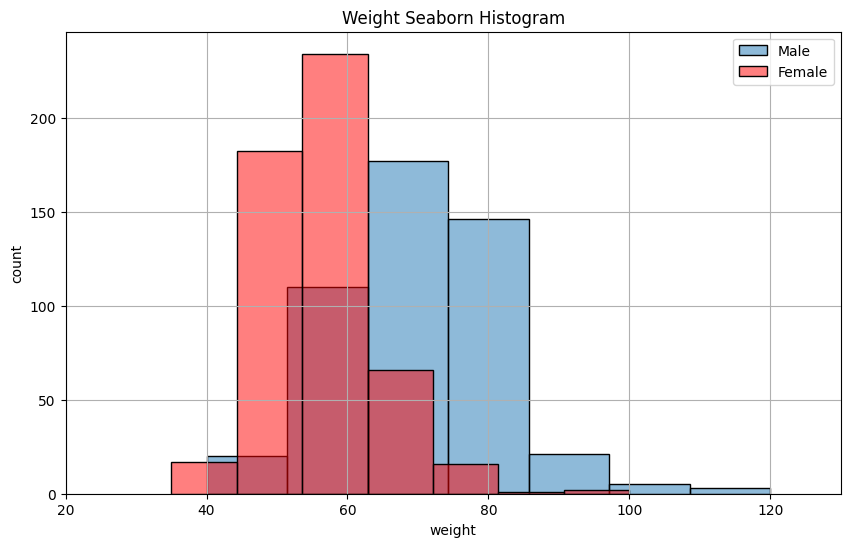

In [7]:
# 6번 문제 : ① = histplot, ② = legend

plt.figure(figsize=(10,6))

sns.histplot(male_data['weight'],   bins=7, alpha=0.5, label='Male')
sns.histplot(female_data['weight'], bins=7, alpha=0.5, label='Female', color='r')

plt.xlim(20,130)
plt.xlabel('weight')
plt.ylabel('count')
plt.title('Weight Seaborn Histogram')
plt.legend()
plt.grid()
plt.show()

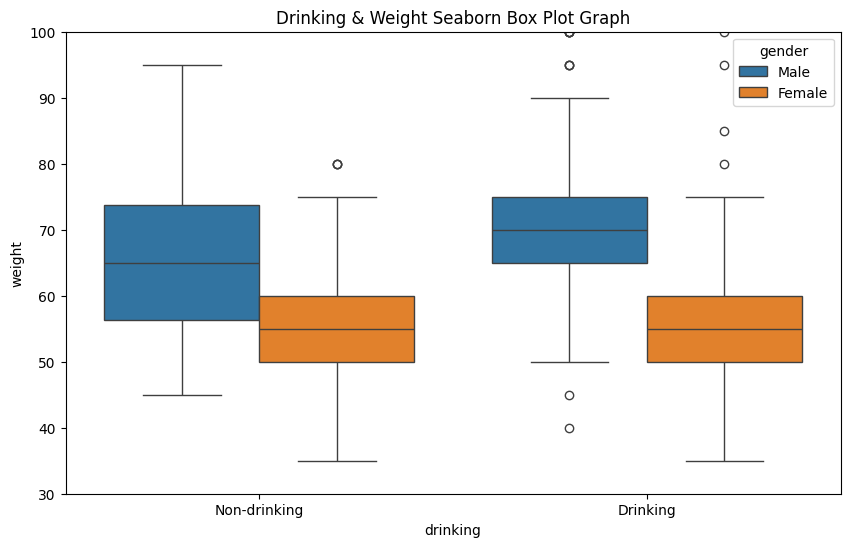

In [8]:
# 7번 문제 : ① = boxplot

plt.figure(figsize=(10,6))
plt.title('Drinking & Weight Seaborn Box Plot Graph')

sns.boxplot(data=data6, x='drinking', y='weight', hue='gender')

plt.ylim(30,100)
plt.show()

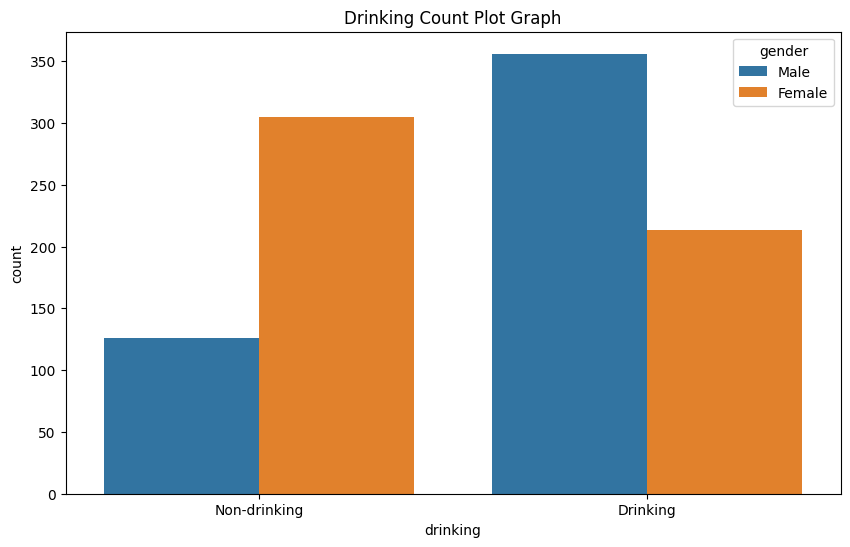

In [9]:
# 8번 문제 : ① = countplot

plt.figure(figsize=(10,6))
plt.title('Drinking Count Plot Graph')

sns.countplot(data=data6, x='drinking', hue='gender')

plt.show()

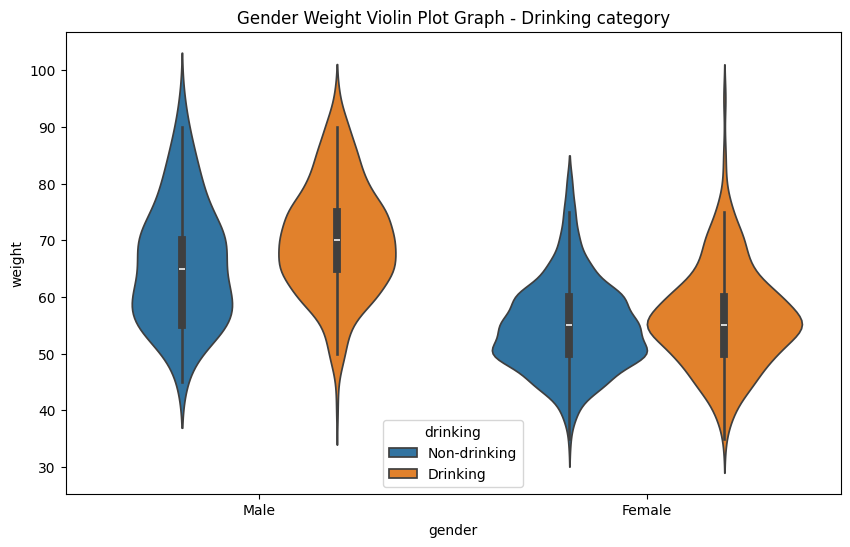

In [10]:
# 9번 문제 : ① = violinplot

plt.figure(figsize=(10,6))
plt.title('Gender Weight Violin Plot Graph - Drinking category')

sns.violinplot(data=data6[data6.weight<100], x='gender', y='weight', hue='drinking')

plt.show()

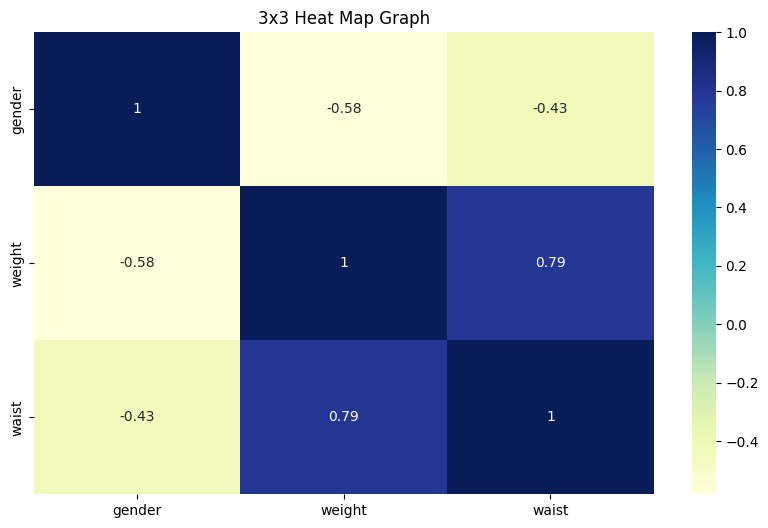

In [ ]:
# 10번 문제 : ① = corr, ② = heatmap

data3 = data.loc[:, ['gender','weight','waist']]

plt.figure(figsize=(10,6))
plt.title('3x3 Heat Map Graph')

correlation_data3 = data3.corr()
sns.heatmap(correlation_data3, annot=True, cmap='YlGnBu')

plt.show()